In [1]:
!pip install ccxt==4.3.90 --force-reinstall --no-cache-dir -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 51.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 185.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 163.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 104.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 136.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 kB 114.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 134.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.6/219.6 kB 180.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.5

In [2]:
!pip install ccxt pandas requests matplotlib seaborn scipy
!pip install google-generativeai -q


📥 Fetching BTC/USDT OHLCV from Gate.io...
   Fetched 1000 candles... (last: 2020-09-26)
   Fetched 2000 candles... (last: 2023-06-23)
   Fetched 2987 candles... (last: 2026-03-06)
   Price available: 2018-01-01 ~ 2026-03-06 (2987 days)

✅ RSI(14) calculated
✅ Analysis period: 2018-05-01 ~ 2025-11-06 (2747 days)

📊 [BTC-USDT] RSI(14) <-> Backward-Looking Return Correlation
  Window              r     p-value  Result
----------------------------------------------------------------------
  1D            +0.3401      0.0000  ✅ Significant
  5D            +0.6739      0.0000  ✅ Significant
  20D           +0.8419      0.0000  ✅ Significant
  60D           +0.6242      0.0000  ✅ Significant
  120D          +0.4156      0.0000  ✅ Significant

📊 [BTC-USDT] RSI(14) <-> Forward Return Correlation (Predictive Test)
  Window              r     p-value  Result
----------------------------------------------------------------------
  1D            +0.0369      0.0440  ✅ Significant
  5D            +0

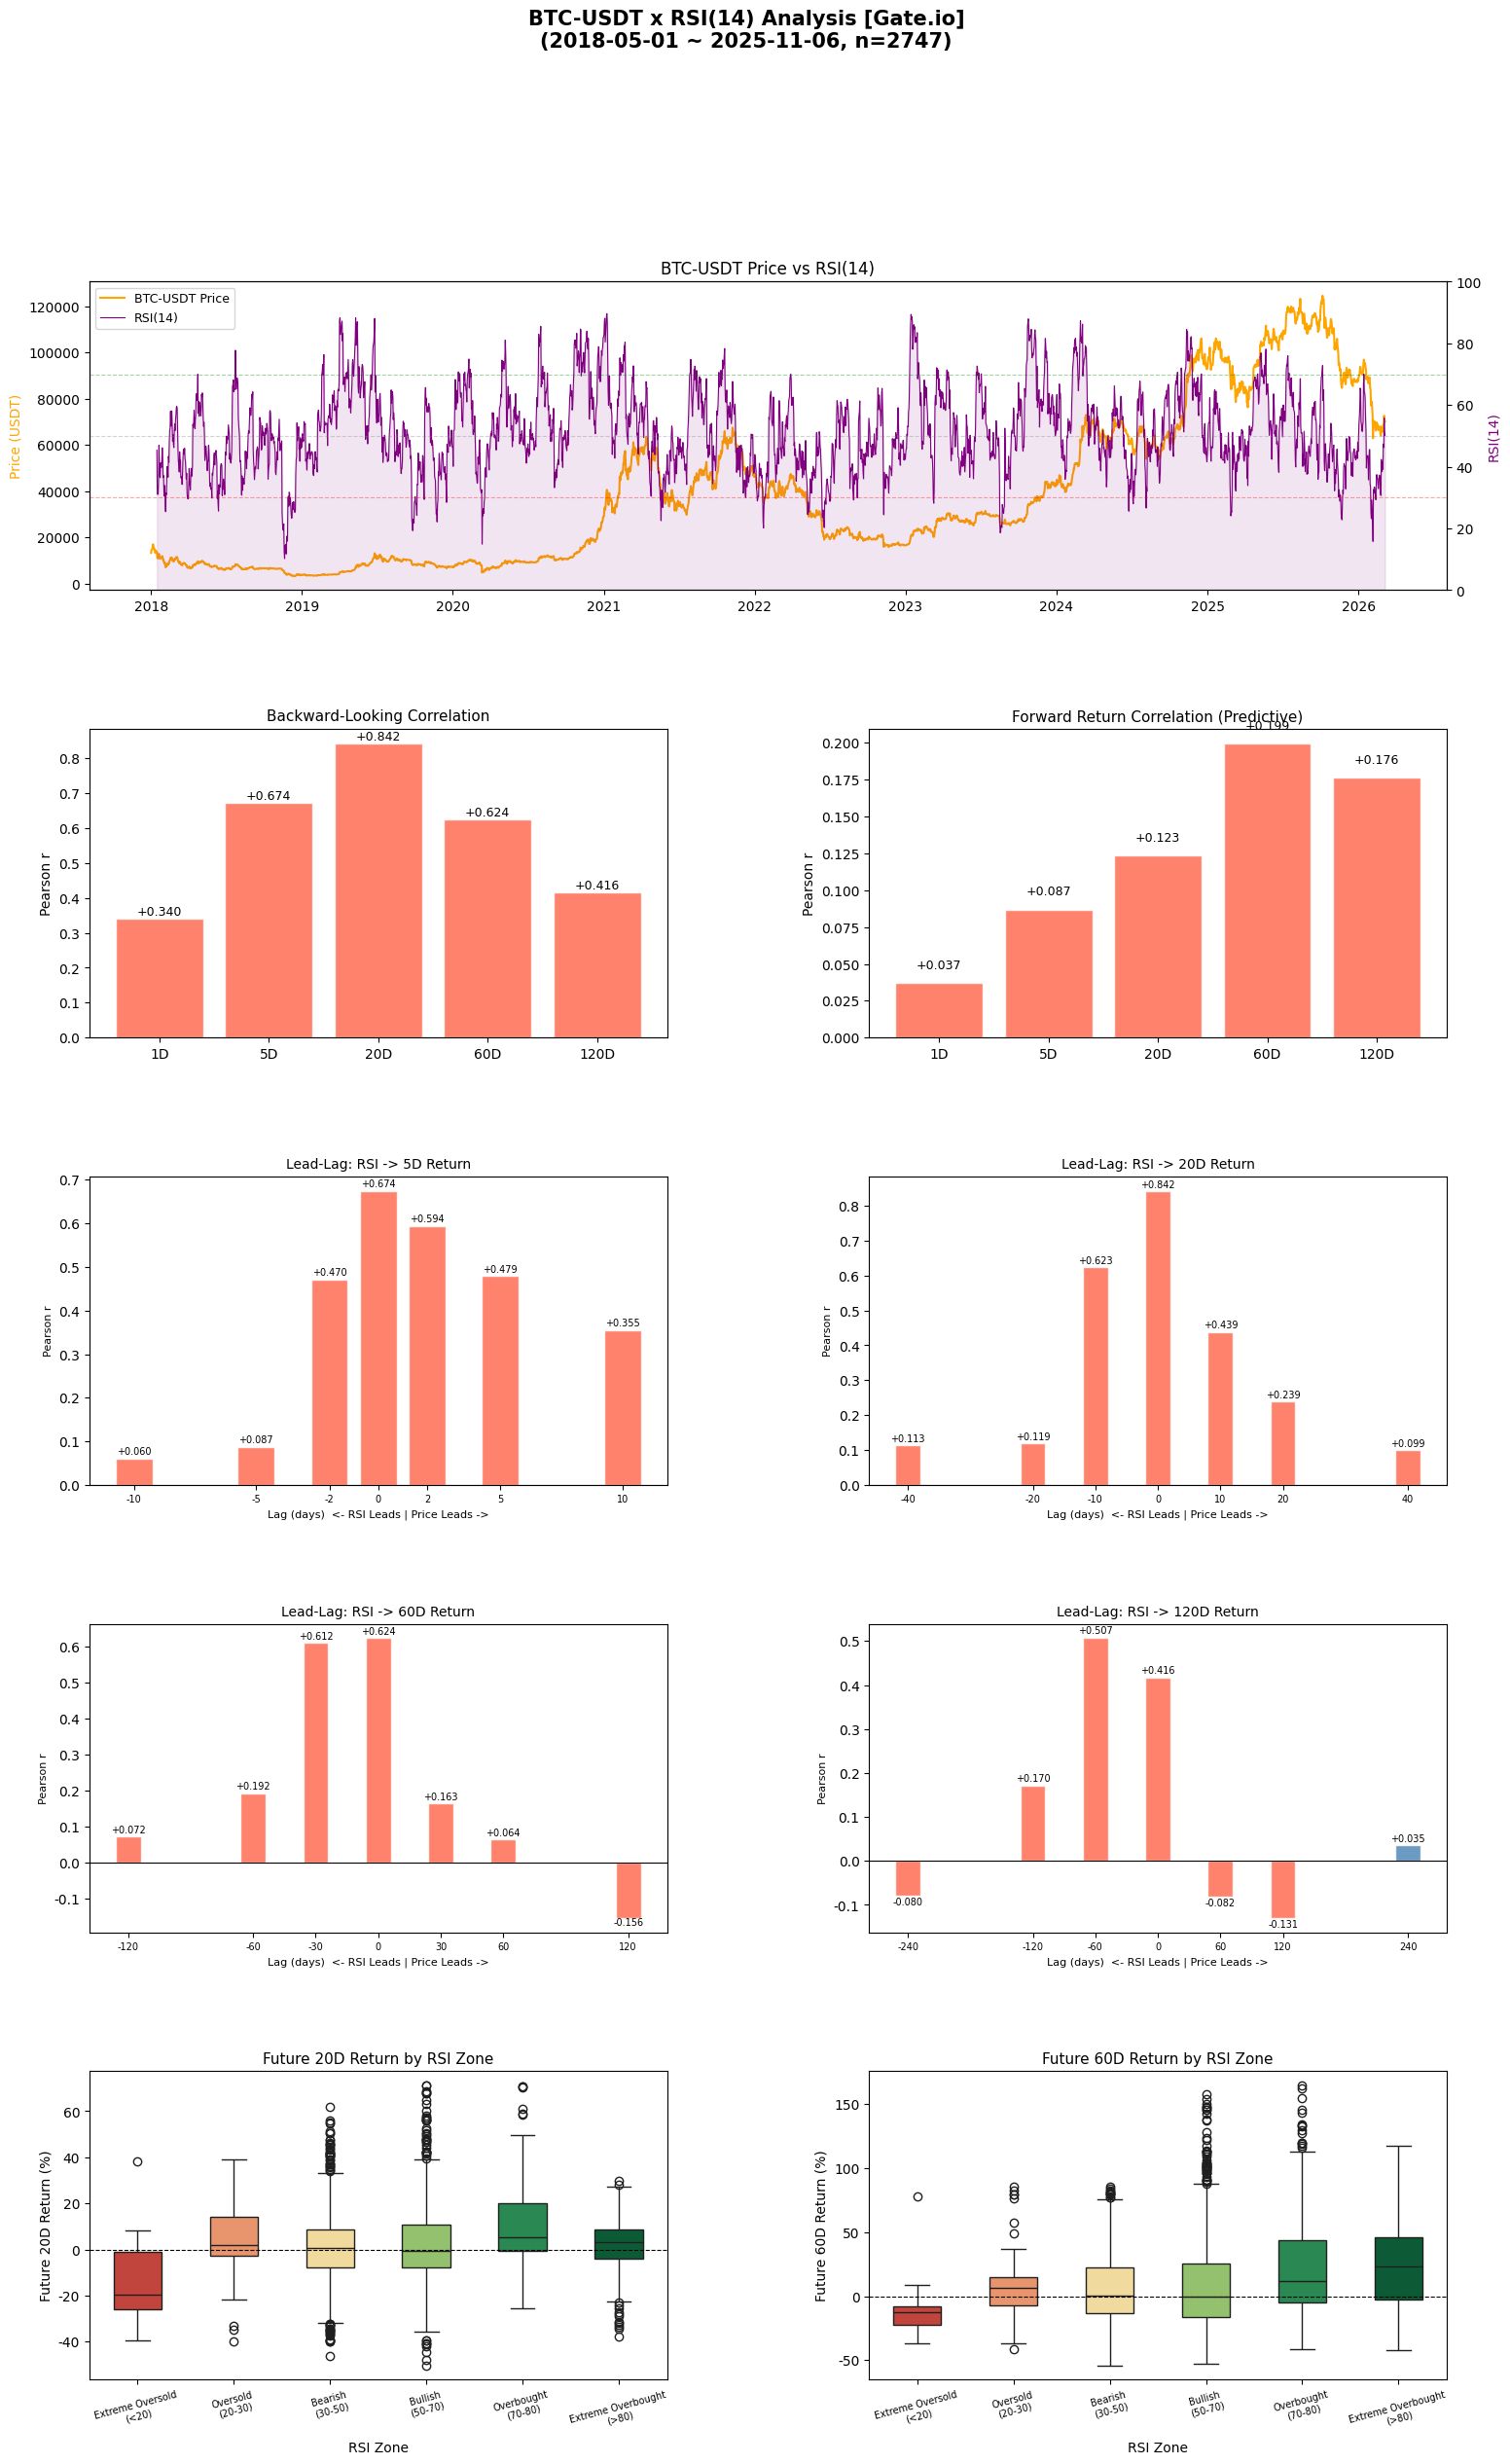


✅ Saved: rsi_BTC-USDT_gateio_analysis.png


In [4]:
import ccxt
import pandas as pd
import requests
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import numpy as np
import warnings
import json
import requests as req
from google.colab import userdata

warnings.filterwarnings('ignore')
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['axes.unicode_minus'] = False

# =====================
# ⚙️ 설정값
# =====================
SYMBOL      = 'BTC/USDT'
START_DATE  = '2018-01-01'
RSI_PERIOD  = 14          # RSI 기간 (보통 14)

PAST_WINDOWS   = [1, 5, 20, 60, 120]
FUTURE_WINDOWS = [1, 5, 20, 60, 120]

# =====================
# 1. Gate.io OHLCV
# =====================
print(f"📥 Fetching {SYMBOL} OHLCV from Gate.io...")
exchange = ccxt.gateio({'enableRateLimit': True})

since_ms = exchange.parse8601(f'{START_DATE}T00:00:00Z') if START_DATE else exchange.parse8601('2015-01-01T00:00:00Z')

all_ohlcv = []
prev_last_ts = None

while True:
    try:
        batch = exchange.fetch_ohlcv(SYMBOL, timeframe='1d', since=since_ms, limit=1000)
    except Exception as e:
        print(f"   ⚠️ Error: {e}")
        break
    if not batch:
        break
    last_ts = batch[-1][0]
    if last_ts == prev_last_ts:
        break
    if all_ohlcv and batch[0][0] == all_ohlcv[-1][0]:
        batch = batch[1:]
    all_ohlcv += batch
    prev_last_ts = last_ts
    since_ms = last_ts + 86400000
    print(f"   Fetched {len(all_ohlcv)} candles... (last: {pd.to_datetime(last_ts, unit='ms').date()})")
    if len(batch) < 1000 or last_ts >= exchange.milliseconds():
        break

df_price = pd.DataFrame(all_ohlcv, columns=['timestamp','open','high','low','close','volume'])
df_price['date'] = pd.to_datetime(df_price['timestamp'], unit='ms').dt.date
df_price = df_price[['date','close']].drop_duplicates('date').reset_index(drop=True)
print(f"   Price available: {df_price['date'].min()} ~ {df_price['date'].max()} ({len(df_price)} days)")

# =====================
# 2. RSI 계산
# =====================
def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df_price['rsi'] = calc_rsi(df_price['close'], RSI_PERIOD)
print(f"\n✅ RSI({RSI_PERIOD}) calculated")

# =====================
# 3. 수익률 계산
# =====================
df = df_price.copy()

for w in PAST_WINDOWS:
    df[f'return_{w}d'] = df['close'].pct_change(w) * 100

for w in FUTURE_WINDOWS:
    df[f'future_return_{w}d'] = (df['close'].shift(-w) / df['close'] - 1) * 100

coin_name = SYMBOL.replace('/', '-')

# RSI 구간 라벨
def rsi_zone_label(v):
    if v < 20:   return 'Extreme Oversold\n(<20)'
    elif v < 30: return 'Oversold\n(20-30)'
    elif v < 50: return 'Bearish\n(30-50)'
    elif v < 70: return 'Bullish\n(50-70)'
    elif v < 80: return 'Overbought\n(70-80)'
    else:        return 'Extreme Overbought\n(>80)'

zone_order = [
    'Extreme Oversold\n(<20)',
    'Oversold\n(20-30)',
    'Bearish\n(30-50)',
    'Bullish\n(50-70)',
    'Overbought\n(70-80)',
    'Extreme Overbought\n(>80)'
]
palette = ['#d73027','#fc8d59','#fee090','#91cf60','#1a9850','#006837']

df['rsi_zone'] = df['rsi'].apply(rsi_zone_label)
df_clean = df.dropna().reset_index(drop=True)

print(f"✅ Analysis period: {df_clean['date'].min()} ~ {df_clean['date'].max()} ({len(df_clean)} days)\n")

# =====================
# 4. 과거 수익률 상관관계
# =====================
print("=" * 70)
print(f"📊 [{coin_name}] RSI({RSI_PERIOD}) <-> Backward-Looking Return Correlation")
print("=" * 70)
print(f"  {'Window':<12} {'r':>8}  {'p-value':>10}  Result")
print("-" * 70)

corr_results = []
for w in PAST_WINDOWS:
    col = f'return_{w}d'
    tmp = df[['rsi', col]].dropna()
    r, p = stats.pearsonr(tmp['rsi'], tmp[col])
    sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    corr_results.append({'window': w, 'r': r, 'p': p})
    print(f"  {str(w)+'D':<12} {r:>+8.4f}  {p:>10.4f}  {sig}")

# =====================
# 5. 미래 수익률 상관관계
# =====================
print("\n" + "=" * 70)
print(f"📊 [{coin_name}] RSI({RSI_PERIOD}) <-> Forward Return Correlation (Predictive Test)")
print("=" * 70)
print(f"  {'Window':<12} {'r':>8}  {'p-value':>10}  Result")
print("-" * 70)

future_corr_results = []
for w in FUTURE_WINDOWS:
    col = f'future_return_{w}d'
    tmp = df[['rsi', col]].dropna()
    r, p = stats.pearsonr(tmp['rsi'], tmp[col])
    sig = "✅ Significant" if p < 0.05 else "❌ Not Significant"
    future_corr_results.append({'window': w, 'r': r, 'p': p})
    print(f"  {str(w)+'D':<12} {r:>+8.4f}  {p:>10.4f}  {sig}")

# =====================
# 6. Lead-Lag
# =====================
print("\n" + "=" * 70)
print(f"📊 [{coin_name}] Lead-Lag Analysis (RSI -> Backward Returns)")
print("=" * 70)

LAG_WINDOWS = [1, 5, 20, 60, 120]
all_lag_results = {}
best_lag_summary = []

for w in LAG_WINDOWS:
    print(f"\n--- {w}D Return ---")
    print(f"{'Lag':>8}  {'r':>8}  {'p-value':>9}  {'Sig':>4}  Interpretation")
    print("-" * 70)

    max_lag = w * 2
    lags = sorted(set([-max_lag, -w, -max(1, w//2), 0, max(1, w//2), w, max_lag]))

    lag_results = []
    for lag in lags:
        col = f'return_{w}d'
        tmp = df[['rsi', col]].dropna().reset_index(drop=True)

        if lag < 0:
            x = tmp['rsi'].iloc[:lag].values
            y = tmp[col].iloc[-lag:].values
            direction = f"RSI leads by {abs(lag)}d"
        elif lag > 0:
            x = tmp['rsi'].iloc[lag:].values
            y = tmp[col].iloc[:-lag].values
            direction = f"Price leads by {lag}d"
        else:
            x = tmp['rsi'].values
            y = tmp[col].values
            direction = "Concurrent"

        r, p = stats.pearsonr(x, y)
        sig = "✅" if p < 0.05 else "  "
        lag_results.append({'lag': lag, 'r': r, 'p': p, 'direction': direction})
        print(f"{lag:>8}  {r:>+8.4f}  {p:>9.4f}  {sig:>4}  {direction}")

    df_lag = pd.DataFrame(lag_results)
    best = df_lag.loc[df_lag['r'].abs().idxmax()]
    print(f"📌 Max: lag={int(best['lag'])}d ({best['direction']}), r={best['r']:+.4f}")

    all_lag_results[w] = lag_results
    best_lag_summary.append({
        'window': w,
        'best_lag': int(best['lag']),
        'best_r': float(best['r']),
        'best_p': float(best['p']),
        'direction': best['direction']
    })

# =====================
# 7. RSI 구간별 미래 수익률
# =====================
print("\n" + "=" * 70)
print(f"📊 [{coin_name}] Future Return by RSI Zone")
print("=" * 70)

zone_stats_all = {}
for w in FUTURE_WINDOWS:
    col = f'future_return_{w}d'
    tmp = df[['rsi_zone', col]].dropna().copy()
    zone_stats = (
        tmp.groupby('rsi_zone')[col]
        .agg(['count','mean','median','std'])
        .reindex(zone_order)
        .reset_index()
    )
    zone_stats_all[w] = zone_stats
    print(f"\n--- Future {w}D Return by RSI Zone ---")
    print(zone_stats.to_string(index=False))

# =====================
# 8. AI 해석
# =====================
print("\n" + "=" * 70)
print(f"🤖 [{coin_name}] AI Interpretation")
print("=" * 70)

GEMINI_API_KEY = userdata.get('GOOGLE_API_KEY')

analysis_data = {
    "coin": coin_name,
    "indicator": f"RSI({RSI_PERIOD})",
    "analysis_period": f"{df_clean['date'].min()} ~ {df_clean['date'].max()} ({len(df_clean)} days)",
    "backward_correlation": [
        {"window": f"{c['window']}D", "r": round(float(c['r']), 4), "p": round(float(c['p']), 4)}
        for c in corr_results
    ],
    "forward_correlation": [
        {"window": f"{c['window']}D", "r": round(float(c['r']), 4), "p": round(float(c['p']), 4)}
        for c in future_corr_results
    ],
    "lead_lag_best": [
        {"return_window": f"{s['window']}D", "best_lag_days": int(s['best_lag']),
         "r": round(float(s['best_r']), 4), "direction": s['direction']}
        for s in best_lag_summary
    ],
    "zone_future_return_mean": {
        f"{w}D": {
            row['rsi_zone'].replace('\n', ' '): None if pd.isna(row['mean']) else round(float(row['mean']), 4)
            for _, row in zone_stats_all[w].iterrows()
        }
        for w in FUTURE_WINDOWS
    }
}

prompt = f"""
You are a quantitative finance analyst.
Interpret the relationship between RSI({RSI_PERIOD}) and {coin_name} price returns.

Analysis Data:
{json.dumps(analysis_data, indent=2)}

Please explain:
1. Backward-looking correlation pattern and what it implies
2. Forward-return (predictive) correlation — can RSI predict future returns?
3. Lead-lag takeaway — does RSI lead or lag price?
4. RSI zone analysis — which zones show the best/worst future returns?
5. One-line overall conclusion

Be specific, data-driven, and reference actual r-values and lag values.
Write in English, 220-320 words.
"""

MODELS = [
    "gemini-2.5-flash-lite",
    "gemini-2.5-flash",
    "gemini-flash-latest",
    "gemini-2.5-pro",
]

text = None
if GEMINI_API_KEY:
    for model_name in MODELS:
        try:
            url = f"https://generativelanguage.googleapis.com/v1beta/models/{model_name}:generateContent?key={GEMINI_API_KEY}"
            resp = req.post(url, json={"contents": [{"parts": [{"text": prompt}]}]}, timeout=30)
            result = resp.json()
            if "candidates" in result:
                text = result["candidates"][0]["content"]["parts"][0]["text"]
                print(f"✅ Model used: {model_name}\n")
                print(text)
                break
            else:
                err_msg = result.get("error", {}).get("message", "Unknown error")
                print(f"⚠️ {model_name} failed: {err_msg.splitlines()[0]}")
        except Exception as e:
            print(f"⚠️ {model_name} error: {e}")

if text is None:
    print("\n⚠️ Gemini unavailable. Using rule-based interpretation.\n")
    backward_df = pd.DataFrame(corr_results)
    best_b = backward_df.loc[backward_df['r'].abs().idxmax()]
    forward_df_r = pd.DataFrame(future_corr_results)
    best_f = forward_df_r.loc[forward_df_r['r'].abs().idxmax()]
    lag_df = pd.DataFrame(best_lag_summary)
    print(f"Strongest backward correlation: {int(best_b['window'])}D (r={best_b['r']:+.4f})")
    print(f"Strongest forward correlation:  {int(best_f['window'])}D (r={best_f['r']:+.4f})")
    print(f"Price leads: {int((lag_df['best_lag']>0).sum())}  |  RSI leads: {int((lag_df['best_lag']<0).sum())}  |  Concurrent: {int((lag_df['best_lag']==0).sum())}")

# =====================
# 9. 시각화
# =====================
fig = plt.figure(figsize=(18, 28))
fig.suptitle(
    f'{coin_name} x RSI({RSI_PERIOD}) Analysis [Gate.io]\n'
    f'({df_clean["date"].min()} ~ {df_clean["date"].max()}, n={len(df_clean)})',
    fontsize=15, fontweight='bold'
)
gs = fig.add_gridspec(5, 2, hspace=0.45, wspace=0.35)

# Chart 1: Price + RSI
ax1 = fig.add_subplot(gs[0, :])
ax2 = ax1.twinx()
ax1.plot(pd.to_datetime(df['date']), df['close'], color='orange', linewidth=1.5, label=f'{coin_name} Price')
ax2.plot(pd.to_datetime(df['date']), df['rsi'], color='purple', linewidth=0.8, label=f'RSI({RSI_PERIOD})')
ax2.fill_between(pd.to_datetime(df['date']), df['rsi'], alpha=0.1, color='purple')
for lvl, col, lbl in [(30,'red','Oversold 30'),(50,'gray','Neutral 50'),(70,'green','Overbought 70')]:
    ax2.axhline(y=lvl, color=col, linestyle='--', alpha=0.35, linewidth=0.8)
ax1.set_ylabel('Price (USDT)', color='orange')
ax2.set_ylabel(f'RSI({RSI_PERIOD})', color='purple')
ax2.set_ylim(0, 100)
ax1.set_title(f'{coin_name} Price vs RSI({RSI_PERIOD})', fontsize=12)
l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, lb1+lb2, loc='upper left', fontsize=9)

# Chart 2: Backward correlation
ax_c1 = fig.add_subplot(gs[1, 0])
r1 = [c['r'] for c in corr_results]
p1 = [c['p'] for c in corr_results]
bars = ax_c1.bar([f'{w}D' for w in PAST_WINDOWS], r1,
                 color=['tomato' if p<0.05 else 'steelblue' for p in p1], alpha=0.8, edgecolor='white')
ax_c1.axhline(0, color='black', linewidth=0.8)
ax_c1.set_title('Backward-Looking Correlation', fontsize=11)
ax_c1.set_ylabel('Pearson r')
for bar, r in zip(bars, r1):
    ax_c1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.01 if r>=0 else -0.02),
               f'{r:+.3f}', ha='center', fontsize=9)

# Chart 3: Forward correlation
ax_c2 = fig.add_subplot(gs[1, 1])
r2 = [c['r'] for c in future_corr_results]
p2 = [c['p'] for c in future_corr_results]
bars2 = ax_c2.bar([f'{w}D' for w in FUTURE_WINDOWS], r2,
                  color=['tomato' if p<0.05 else 'steelblue' for p in p2], alpha=0.8, edgecolor='white')
ax_c2.axhline(0, color='black', linewidth=0.8)
ax_c2.set_title('Forward Return Correlation (Predictive)', fontsize=11)
ax_c2.set_ylabel('Pearson r')
for bar, r in zip(bars2, r2):
    ax_c2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+(0.01 if r>=0 else -0.02),
               f'{r:+.3f}', ha='center', fontsize=9)

# Chart 4~7: Lead-Lag
positions = [(2,0),(2,1),(3,0),(3,1)]
for idx, w in enumerate([5, 20, 60, 120]):
    row, col = positions[idx]
    ax = fig.add_subplot(gs[row, col])
    df_lag = pd.DataFrame(all_lag_results[w])
    lag_colors = ['tomato' if p<0.05 else 'steelblue' for p in df_lag['p']]
    bar_width = max(df_lag['lag'].diff().dropna().abs().min() * 0.4, 1.5)
    ax.bar(df_lag['lag'], df_lag['r'], width=bar_width, color=lag_colors, alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lead-Lag: RSI -> {w}D Return', fontsize=10)
    ax.set_xlabel('Lag (days)  <- RSI Leads | Price Leads ->', fontsize=8)
    ax.set_ylabel('Pearson r', fontsize=8)
    ax.set_xticks(df_lag['lag'].tolist())
    ax.tick_params(axis='x', labelsize=7)
    for _, row_data in df_lag.iterrows():
        ax.text(row_data['lag'], row_data['r']+(0.01 if row_data['r']>=0 else -0.02),
                f"{row_data['r']:+.3f}", ha='center', fontsize=7)

# Chart 8: Zone vs future 20D
ax_z1 = fig.add_subplot(gs[4, 0])
tmp20 = df[['rsi_zone','future_return_20d']].dropna().copy()
sns.boxplot(data=tmp20, x='rsi_zone', y='future_return_20d',
            order=zone_order, palette=palette, ax=ax_z1, width=0.5)
ax_z1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_z1.set_title('Future 20D Return by RSI Zone', fontsize=11)
ax_z1.set_xlabel('RSI Zone')
ax_z1.set_ylabel('Future 20D Return (%)')
ax_z1.tick_params(axis='x', rotation=15, labelsize=7)

# Chart 9: Zone vs future 60D
ax_z2 = fig.add_subplot(gs[4, 1])
tmp60 = df[['rsi_zone','future_return_60d']].dropna().copy()
sns.boxplot(data=tmp60, x='rsi_zone', y='future_return_60d',
            order=zone_order, palette=palette, ax=ax_z2, width=0.5)
ax_z2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax_z2.set_title('Future 60D Return by RSI Zone', fontsize=11)
ax_z2.set_xlabel('RSI Zone')
ax_z2.set_ylabel('Future 60D Return (%)')
ax_z2.tick_params(axis='x', rotation=15, labelsize=7)

plt.savefig(f'rsi_{coin_name}_gateio_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Saved: rsi_{coin_name}_gateio_analysis.png")